# Computer Vision, Assignment 3: Epipolar Geometry

In this assignment, you will study epipolar geometry. 
You will use the fundamental matrix and the essential matrix for simultaneously reconstructing the 3D structure and the camera motion from two images.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade.
All computer exercises that are not marked **OPTIONAL** are ``mandatory'' in the sense described on Canvas.


### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).

In [1]:
import cv2
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.io
from supplied import pflat, plot_camera, rital

# The Fundamental Matrix

#### *Theoretical exercises 1-4* (see pdf)

## Computer Exercise 1
<figure align="center">
    <img alt="left" src="data/kronan1.JPG" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="data/kronan2.JPG" width="250px">
    <figcaption>Figure1. kronan1.jpg and kronan2.jpg</figcaption>
</figure>

In this exercise you will compute the fundamental matrix for the two images above, showing a part of the fort Kronan in Gothenburg. The calibration matrix $K$ is assumed to be unknown. The file `compEx1data.mat` contains a cell `x` with matched points for the two images.

### Task 1.1
Compute normalization matrices $N_1$ and $N_2$. These matrices should subtract the mean and re-scale using the standard deviation, as in assignment 2.
Normalize the image points of the two images with $N_1$ and $N_2$, respectively.

In [2]:
data = scipy.io.loadmat('data/compEx1data.mat')
x_cell = data['x']          # MATLAB cell array -> NumPy object array

# Extract matched points for image 1 and 2
if x_cell.shape == (2, 1):          # 2x1 cell array
    x1 = x_cell[0, 0]
    x2 = x_cell[1, 0]
elif x_cell.shape == (1, 2):        # 1x2 cell array (other exercises)
    x1 = x_cell[0, 0]
    x2 = x_cell[0, 1]
else:
    raise ValueError(f"Unexpected shape for x: {x_cell.shape}")

def to_homogeneous(x):
    if x.shape[0] == 2:
        return np.vstack((x, np.ones((1, x.shape[1]))))
    elif x.shape[0] == 3:
        return x / x[2]
    else:
        raise ValueError("x must be 2xN or 3xN")

def normalize_points(x):
    x = x / x[2]

    u = x[0]
    v = x[1]

    mu_u = np.mean(u)
    mu_v = np.mean(v)
    std_u = np.std(u)
    std_v = np.std(v)

    N = np.array([[1.0 / std_u, 0.0,        -mu_u / std_u],
                  [0.0,         1.0 / std_v, -mu_v / std_v],
                  [0.0,         0.0,         1.0]])

    x_norm = N @ x
    return x_norm, N

x1_h = to_homogeneous(x1)
x2_h = to_homogeneous(x2)

x1n, N1 = normalize_points(x1_h)
x2n, N2 = normalize_points(x2_h)

print("N1 =\n", N1)
print("N2 =\n", N2)

N1 =
 [[ 0.00238     0.         -2.02599909]
 [ 0.          0.00300312 -2.00511271]
 [ 0.          0.          1.        ]]
N2 =
 [[ 0.00220246  0.         -1.67486982]
 [ 0.          0.00288869 -1.91860117]
 [ 0.          0.          1.        ]]


### Task 1.2
Set up the matrix $M$ in the eight point algorithm (8 is the minimum number of points, you should use all the points here), and solve the homogeneous least squares system using SVD. 
Check that the minimum singular value and $||Mv||$ are both small. Construct the $3 \times 3$ matrix $\tilde F$ from the solution $v$. This matrix should approximately satisfy $\tilde x_2^T \tilde F \tilde x_1 = 0$, where $\tilde x_j$ are normalized image points. Write the code as a function which would be useful later. 

In [3]:
def estimate_F_DLT(x1s, x2s):
    '''
    x1s and x2s contain matching points
    x1s - 2D image points in the first image in homogenous coordinates (3xN)
    x2s - 2D image points in the second image in homogenous coordinates (3xN)

    Returns:
        F_tilde : 3x3 fundamental matrix estimated with DLT on normalized points
        s_min   : smallest singular value of M
        Mv_norm : || M v ||_2 for the solution vector v
    '''

    # Ensure homogeneous coordinates are normalized (last row = 1)
    x1 = pflat(x1s)
    x2 = pflat(x2s)

    assert x1.shape[1] == x2.shape[1], "x1s and x2s must have the same number of points"
    n = x1.shape[1]

    # Inhomogeneous coordinates
    x  = x1[0, :]
    y  = x1[1, :]
    xp = x2[0, :]
    yp = x2[1, :]

    # Build the M matrix (n x 9) for the eight-point algorithm
    # Each row corresponds to: [x' x, x' y, x', y' x, y' y, y', x, y, 1]
    M = np.zeros((n, 9))
    M[:, 0] = xp * x
    M[:, 1] = xp * y
    M[:, 2] = xp
    M[:, 3] = yp * x
    M[:, 4] = yp * y
    M[:, 5] = yp
    M[:, 6] = x
    M[:, 7] = y
    M[:, 8] = 1.0

    # Solve the homogeneous least-squares problem M v = 0 using SVD
    U, S, Vt = np.linalg.svd(M)
    v = Vt[-1, :]          # Right singular vector corresponding to smallest singular value

    # Reshape to 3x3 matrix F_tilde
    F_tilde = v.reshape(3, 3)

    # Diagnostics: smallest singular value and ||M v||
    s_min = S[-1]
    Mv_norm = np.linalg.norm(M @ v)

    # print checks; comment out if not desired
    print("Minimum singular value of M:", s_min)
    print("Norm of Mv:", Mv_norm)

    return F_tilde, s_min, Mv_norm

You must also make sure that $\det(\tilde{F}) = 0$ for your solution. Make a separate function that explicitly enforces the constraint, as this will be convenient for you later.

In [4]:
def enforce_fundamental(F_approx):
    '''
    F_approx - Approximate Fundamental matrix (3x3)
    Returns:
        F_rank2 - Fundamental matrix with det(F_rank2) = 0 (rank-2 enforced)
    '''

    # Singular Value Decomposition
    U, S, Vt = np.linalg.svd(F_approx)

    # Enforce rank-2 by setting the smallest singular value to zero
    S_enforced = np.diag(S)
    S_enforced[-1, -1] = 0.0

    # Reconstruct the fundamental matrix with rank 2
    F_rank2 = U @ S_enforced @ Vt

    return F_rank2

Estimate $\tilde{F}$ and check that the epipolar constraints $\tilde{x}_2^T \tilde{F} \tilde{x}_1 = 0$ are roughly fulfilled.


In [5]:
# 1. Estimate F~ using normalized points
F_approx, s_min, Mv_norm = estimate_F_DLT(x1n, x2n)

# 2. Enforce det(F~) = 0 (rank-2 constraint)
F_tilde = enforce_fundamental(F_approx)

print("det(F_tilde) =", np.linalg.det(F_tilde))

# 3. Check epipolar constraints  x2^T F x1 ≈ 0  for all correspondences
Fx1 = F_tilde @ x1n                 # 3xN
x2T_F_x1 = np.sum(x2n * Fx1, axis=0)  # length-N array of residuals

# Basic statistics of the residuals
print("Epipolar residuals (x2^T F x1):")
print("  mean abs =", np.mean(np.abs(x2T_F_x1)))
print("  max abs  =", np.max(np.abs(x2T_F_x1)))

# If you want to see a few sample values:
print("  first 10 residuals:", x2T_F_x1[:10])

Minimum singular value of M: 0.04965450019510742
Norm of Mv: 0.049654500195106886
det(F_tilde) = -5.980864892638752e-19
Epipolar residuals (x2^T F x1):
  mean abs = 0.0007158981329757784
  max abs  = 0.007951132480184087
  first 10 residuals: [ 2.15330678e-05  1.52107351e-03  7.36804486e-04 -5.45285160e-04
  1.00965563e-03 -9.13999810e-05  1.55415942e-03 -1.63054972e-03
 -1.23272502e-03 -1.39041592e-03]


### Task 1.3



Compute the un-normalized fundamental matrix $F$ (using the formula from exercise 4) and the epipolar lines $l = F x_1$. Pick 20 points in the second image at random and plot these in the same figure as the image.
Also plot the corresponding epipolar lines in the same image using the function `rital`. Verify that the points are close to the corresponding epipolar lines.





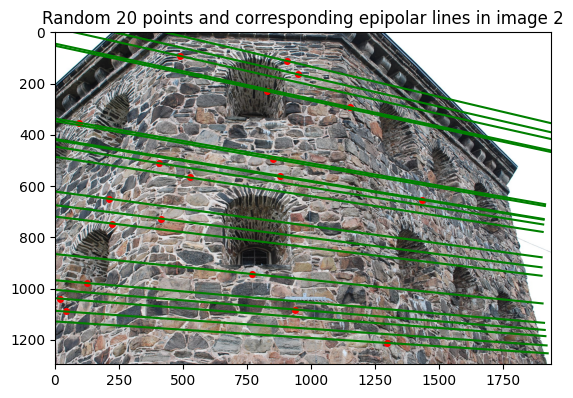

Mean point-line distance (pixels): 0.30329236743328475
Max  point-line distance (pixels): 0.7942975896820995


In [6]:
# 1. Denormalize to obtain the fundamental matrix in original coordinates
#    F = N2^T * F_tilde * N1
F = N2.T @ F_tilde @ N1

# 2. Compute epipolar lines in image 2 for all points in image 1
#    l2_i = F x1_i  (each column is a line in homogeneous form)
l2 = F @ x1        # 3xN
l2 = l2.T          # N x 3, as expected by rital (rows = lines)

# 3. Choose 20 random correspondences
N_pts = x1.shape[1]
num_show = min(20, N_pts)
idx = np.random.choice(N_pts, size=num_show, replace=False)

# Points in image 2 (inhomogeneous for plotting)
x2_plot = pflat(x2[:, idx])      # 3 x num_show
x2u = x2_plot[0, :]
x2v = x2_plot[1, :]

# Corresponding epipolar lines in image 2
l2_show = l2[idx, :]            # num_show x 3

# 4. Plot image 2, the selected points, and their epipolar lines
img2 = mpimg.imread('data/kronan2.jpg')

fig, ax = plt.subplots()
ax.imshow(img2)
ax.plot(x2u, x2v, 'ro', markersize=4)   # points in second image
plt.axis('image')
plt.title('Random 20 points and corresponding epipolar lines in image 2')

# rital uses current axes; pass the subset of lines
rital(l2_show, 'g-')            # draw epipolar lines

plt.show()

# 5. verify numerically that points are close to lines
#    distance from point x2 to line l2: |l^T x| / sqrt(a^2 + b^2)
x2_h = x2[:, idx]               # 3 x num_show
num = np.abs(np.sum(l2_show * x2_h.T, axis=1))           # |l^T x|
den = np.sqrt(l2_show[:, 0]**2 + l2_show[:, 1]**2)
dists = num / den

print("Mean point-line distance (pixels):", np.mean(dists))
print("Max  point-line distance (pixels):", np.max(dists))

Compute the distance between all the points and their corresponding epipolar lines and plot these in a histogram with 100 bins.
What is the mean distance? Create a function as this would be useful later.

In [7]:
def compute_epipolar_errors(F, x1s, x2s):
    '''
    x1s and x2s contain matching points
    x1s - 2D image points in the first image in homogenous coordinates (3xN)
    x2s - 2D image points in the second image in homogenous coordinates (3xN)
    F   - Fundamental matrix (3x3)

    Returns:
        dists      - 1D array of point-to-line distances (pixels)
        mean_dist  - mean of these distances
    '''

    # Ensure homogeneous normalization
    x1 = pflat(x1s)
    x2 = pflat(x2s)

    # Epipolar lines in image 2 corresponding to points in image 1
    # l2_i = F x1_i
    l2 = F @ x1                # 3xN
    l2 = l2.T                  # N x 3, each row: [a, b, c]

    # Distances from x2 points to corresponding epipolar lines l2
    x2h = x2.T                 # N x 3
    num = np.abs(np.sum(l2 * x2h, axis=1))           # |l^T x|
    den = np.sqrt(l2[:, 0]**2 + l2[:, 1]**2)         # sqrt(a^2 + b^2)
    dists = num / den                                  # N distances in pixels

    mean_dist = np.mean(dists)

    # Plot histogram with 100 bins
    plt.figure()
    plt.hist(dists, bins=100)
    plt.xlabel('Epipolar distance (pixels)')
    plt.ylabel('Count')
    plt.title('Histogram of epipolar point-line distances')
    plt.show()

    print("Mean epipolar distance:", mean_dist)

    return dists, mean_dist

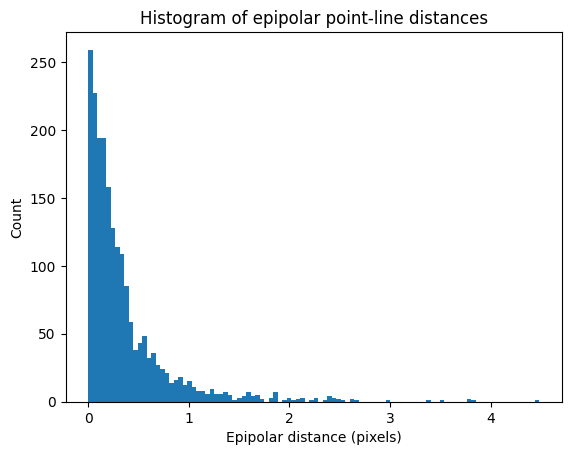

Mean epipolar distance: 0.36123310274799


In [8]:
# Compute epipolar distances for all matches
dists, mean_dist = compute_epipolar_errors(F, x1, x2)

#### Your answer here: 

The mean distance with normalization is: 0.36123310274799

### Task 1.4

See what happens if we do everything without normalization (that is, set $N_1=N_2=I$ and run the code again).
What is the mean distance in this case?

Minimum singular value of M: 0.5629347767539168
Norm of Mv: 0.5629347767539139
det(F_no) = 1.1408332205698904e-24
min singular value (no norm) = 0.5629347767539168
||M v|| (no norm) = 0.5629347767539139


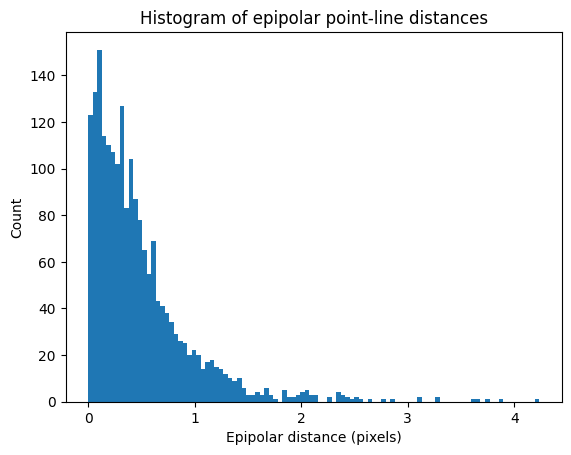

Mean epipolar distance: 0.48784035810442683


In [9]:
# Identity normalization matrices
N1_no = np.eye(3)
N2_no = np.eye(3)

# Estimate F directly from the original homogeneous points
F_approx_no, s_min_no, Mv_norm_no = estimate_F_DLT(x1, x2)

# Enforce rank-2 constraint (det(F) = 0)
F_no = enforce_fundamental(F_approx_no)

print("det(F_no) =", np.linalg.det(F_no))
print("min singular value (no norm) =", s_min_no)
print("||M v|| (no norm) =", Mv_norm_no)

# Compute mean epipolar distance for this case
dists_no, mean_dist_no = compute_epipolar_errors(F_no, x1, x2)

#### Your answer here: 

The mean distance without normalization is: 0.48784035810442683


#### *Theoretical exercise 5* (see pdf)

# The Essential Matrix

#### *Theoretical exercise 6* (see pdf)

## Computer Exercise 2


### Task 2.1

The file `compEx2data.mat` contains the calibration matrix $K$ for the two images in Computer Exercise 1. 
Normalize the image points using the inverse of $K$.

Set up the matrix $M$ in the eight point algorithm, and solve the homogeneous least squares system using SVD. Check that the minimum singular value and $Mv$ are both small. You can of course re-use function `estimate_F_DLT`.

Construct the essential matrix from the solution $v$. Don't forget to make sure that $E$ has two equal singular values and the third one zero.
As the essential matrix is a homogeneous entity, scale does not matter, but for grading purposes, please also make sure that the two non-zero singular values are both equal to 1.
Check that the epipolar constraints $\tilde{x}_2^T E\tilde{x}_1 = 0$ are roughly fulfilled.

In [10]:
def enforce_essential(E_approx):
    '''
    E_approx - Approximate Essential matrix (3x3)

    Returns:
        E - Essential matrix with singular values (1, 1, 0)
    '''

    # SVD of the approximate essential matrix
    U, S, Vt = np.linalg.svd(E_approx)

    # Enforce the internal constraints:
    # two equal non-zero singular values (set to 1) and one zero
    S_new = np.diag([1.0, 1.0, 0.0])

    # Reconstruct the constrained essential matrix
    E = U @ S_new @ Vt

    return E

In [11]:
# Load calibration matrix K
data2 = scipy.io.loadmat('data/compEx2data.mat')
K_raw = data2['K']

# Handle both possible formats: single 3x3, or 3x3x2 (same intrinsics for both views)
if K_raw.shape == (3, 3):
    K1 = K2 = K_raw
elif K_raw.shape[0:2] == (3, 3):
    # If K is 3x3x2, assume K[:,:,0] for image 1 and K[:,:,1] for image 2
    K1 = K_raw[:, :, 0]
    K2 = K_raw[:, :, 1]
else:
    raise ValueError(f"Unexpected K shape: {K_raw.shape}")

K1_inv = np.linalg.inv(K1)
K2_inv = np.linalg.inv(K2)

# Normalize the image points  (x̃ = K^{-1} x)
x1_tilde = K1_inv @ x1     # 3xN
x2_tilde = K2_inv @ x2     # 3xN


# Set up the matrix M in eight point algorithm and solve for v
# Re-use the DLT function; on normalized camera coordinates it returns an essential matrix
E_approx, s_min, Mv_norm = estimate_F_DLT(x1_tilde, x2_tilde)

# Check that minimum singular value and Mv both are small
print("Min singular value (E case):", s_min)
print("||M v|| (E case):", Mv_norm)


# Construct essential matrix from v (Ensuring that the two non-zero singular values are both equal to 1)
E = enforce_essential(E_approx)

# Inspect singular values to confirm they are [1, 1, 0] approximately
U_E, S_E, Vt_E = np.linalg.svd(E)
print("Singular values of enforced E:", S_E)


# Check that epipolar constraints are roughly fulfilled: x̃2^T E x̃1 ≈ 0
Fx1_cam = E @ x1_tilde                         # 3xN
residuals = np.sum(x2_tilde * Fx1_cam, axis=0)  # length-N array of x̃2^T E x̃1

print("Mean |x2^T E x1|:", np.mean(np.abs(residuals)))
print("Max  |x2^T E x1|:", np.max(np.abs(residuals)))
print("First 10 residuals:", residuals[:10])

Minimum singular value of M: 0.006626799894543153
Norm of Mv: 0.006626799894543135
Min singular value (E case): 0.006626799894543153
||M v|| (E case): 0.006626799894543135
Singular values of enforced E: [1.00000000e+00 1.00000000e+00 5.09174717e-17]
Mean |x2^T E x1|: 0.0008038774006372452
Max  |x2^T E x1|: 0.0025874977762773838
First 10 residuals: [-1.35914450e-03 -1.48347818e-03 -1.51997656e-03 -2.64050965e-05
 -7.14086443e-04 -1.29595412e-04 -1.63090832e-03 -7.63234487e-04
 -7.36012960e-04 -1.01239807e-03]


### Task 2.2

Compute the fundamental matrix for the un-normalized coordinate system from the essential matrix and compute the epipolar lines $l = F  x_1$. Pick 20 of the detected points in the second image
at random and plot these in the same figure as the image. Also plot the corresponding epipolar lines in the same figure using the function `rital`.

Compute the distance between the points and their corresponding epipolar lines and plot these in a histogram with 100 bins. 
**How does this result compare to the corresponding result in Computer Exercise 1?** If the errors are higher, remember that we are dealing with noisy measurements, and for the essential matrix we enforce more constraints than for the fundamental matrix. Write the following function that will be helpful for the rest of the course.

In [22]:
# Note that we in this case have K1=K2=K

def convert_E_to_F(E, K1, K2):
    '''
    A function that gives you a fundamental matrix from an essential matrix and the two calibration matrices
    E  - Essential matrix (3x3)
    K1 - Calibration matrix for the first image (3x3)
    K2 - Calibration matrix for the second image (3x3)
    '''
    K1_inv = np.linalg.inv(K1)
    K2_inv_T = np.linalg.inv(K2).T   # (K2^{-1})^T = K2^{-T}

    F = K2_inv_T @ E @ K1_inv
    return F

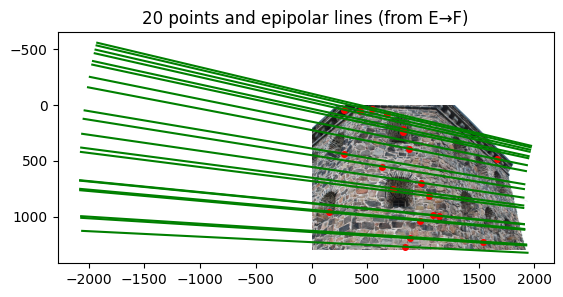

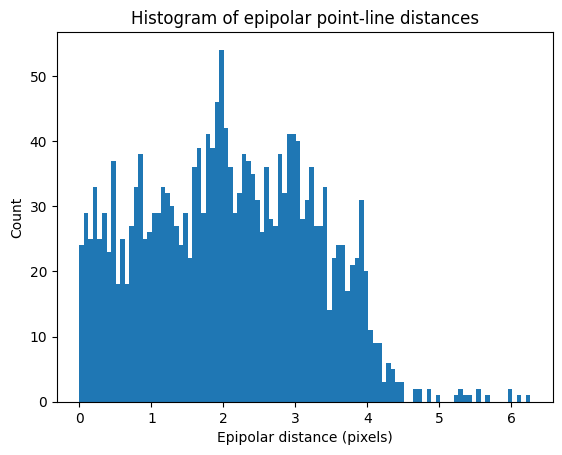

Mean epipolar distance: 2.0837532026927397
Mean epipolar distance (from E→F): 2.0837532026927397


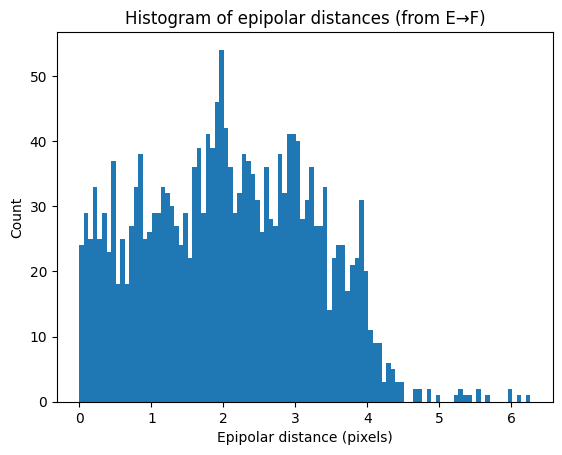

In [23]:
# Compute the fundamental matrix from the essential matrix and compute the epipolar lines
F_from_E = convert_E_to_F(E, K1, K2)          # F = K^{-T} E K^{-1}

# Epipolar lines in image 2 for all points in image 1: l2_i = F x1_i
l2_all = (F_from_E @ x1).T                 # N x 3, each row is [a,b,c] for one line

# Plot 20 of the detected points and corresponding epipolar lines in the same figure as the image
N_pts = x2.shape[1]
num_show = min(20, N_pts)
idx = np.random.choice(N_pts, size=num_show, replace=False)

x2_plot = pflat(x2[:, idx])               # 3 x num_show
x2u, x2v = x2_plot[0, :], x2_plot[1, :]

l2_show = l2_all[idx, :]                  # num_show x 3

img2 = mpimg.imread('data/kronan2.jpg')
fig, ax = plt.subplots()
ax.imshow(img2)
ax.plot(x2u, x2v, 'ro', markersize=4)
rital(l2_show, 'g-')                      # draw the corresponding epipolar lines
plt.axis('image')
plt.title('20 points and epipolar lines (from E→F)')
plt.show()

# Compute the distance between the points and their corresponding epipolar lines
# and plot these in a histogram
dists_EF, mean_dist_EF = compute_epipolar_errors(F_from_E, x1, x2)
print("Mean epipolar distance (from E→F):", mean_dist_EF)

plt.figure()
plt.hist(dists_EF, bins=100)
plt.xlabel('Epipolar distance (pixels)')
plt.ylabel('Count')
plt.title('Histogram of epipolar distances (from E→F)')
plt.show()

### Your answer here: 

(*Include an answer to the question marked in bold.*)
### The mean epipolar distance becomes larger and the range of epipolar point-line distances differ considerably.

#### *Theoretical exercise 7* (see pdf)

## Computer Exercise 3


### Task 3.1

\begin{equation}
P_2 = [UWV^T \ u_3] \text{ or } [UWV^T \ -u_3]  \text{ or }
[UW^TV^T \ u_3]  \text{ or } [ UW^TV^T \ -u_3 ]
\end{equation}


For the essential matrix obtained in Computer Exercise 2 compute the four camera solutions above (make sure that `det(U*V') > 0`; otherwise set `V = -V`).

Write a function that does this for you, it will also be useful in the future. The output `P` should contain all four solutions.

In [30]:
def extract_P_from_E(E):
    '''
    A function that extracts the four P2 solutions
    E - Essential matrix (3x3)
    Returns:
        P - Array containing all four P2 solutions (4 x 3 x 4),
            where P[i, :, :] is the i-th 3x4 camera matrix
    '''

    # SVD of E: E = U * diag(1,1,0) * V^T  (approximately)
    U, S, Vt = np.linalg.svd(E)

    # Ensure det(U * V^T) > 0; if not, flip the sign of V
    if np.linalg.det(U @ Vt) < 0:
        Vt = -Vt

    # Standard W matrix used in E decomposition
    W = np.array([[0, -1, 0],
                  [1,  0, 0],
                  [0,  0, 1]])

    u3 = U[:, 2].reshape(3, 1)   # third column of U as a 3x1 vector

    P = np.zeros((4, 3, 4))

    # P2 = [U W V^T |  ±u3] and [U W^T V^T | ±u3]
    R1 = U @ W  @ Vt
    R2 = U @ W.T @ Vt

    P[0, :, :] = np.hstack((R1,  u3))
    P[1, :, :] = np.hstack((R1, -u3))
    P[2, :, :] = np.hstack((R2,  u3))
    P[3, :, :] = np.hstack((R2, -u3))

    return P

In [31]:
# Extract P2 from E
P2_candidates = extract_P_from_E(E)

# P2_candidates has shape (4, 3, 4); for example:
print("Number of P2 solutions:", P2_candidates.shape[0])
for i in range(4):
    print(f"P2 solution {i} =\n", P2_candidates[i])

Number of P2 solutions: 4
P2 solution 0 =
 [[ 0.99438445  0.02933304  0.10168156  0.92229092]
 [-0.03112361  0.99938639  0.01606773  0.14220198]
 [-0.10114785 -0.01914219  0.99468723  0.35938565]]
P2 solution 1 =
 [[ 0.99438445  0.02933304  0.10168156 -0.92229092]
 [-0.03112361  0.99938639  0.01606773 -0.14220198]
 [-0.10114785 -0.01914219  0.99468723 -0.35938565]]
P2 solution 2 =
 [[ 0.62208686  0.27002211  0.73491224  0.92229092]
 [ 0.28035671 -0.95323078  0.11292118  0.14220198]
 [ 0.73103218  0.13579079 -0.66869485  0.35938565]]
P2 solution 3 =
 [[ 0.62208686  0.27002211  0.73491224 -0.92229092]
 [ 0.28035671 -0.95323078  0.11292118 -0.14220198]
 [ 0.73103218  0.13579079 -0.66869485 -0.35938565]]


Triangulate the points using DLT for each of the four camera solutions, and determine for which of the solutions the points are in front of the cameras.
In this exercise, you may expect to have only one solution for which all the 3D points are in front of both cameras. But in general, since there is noise involved it might not be possible to find a solution with all points in front of the cameras. (In that case the solution with the highest number of points in front of the cameras needs to be selected.)

In [32]:
# P1 for normalized cameras (from E): first camera at origin, looking along +Z
P1 = np.hstack((np.eye(3), np.zeros((3, 1))))

def triangulate_points_DLT(P1, P2, x1_tilde, x2_tilde):
    """
    Linear DLT triangulation for all point pairs for one camera pair.
    P1, P2 : 3x4 camera matrices
    x1_tilde, x2_tilde : 3xN normalized image points (homogeneous)
    Returns:
        X : 4xN homogeneous 3D points
    """
    n = x1_tilde.shape[1]
    X = np.zeros((4, n))

    for i in range(n):
        x1 = x1_tilde[:, i] / x1_tilde[2, i]
        x2 = x2_tilde[:, i] / x2_tilde[2, i]

        # Build A (4x4) for DLT: (u * p3^T - p1^T, v * p3^T - p2^T) for each camera
        A = np.zeros((4, 4))
        A[0] = x1[0] * P1[2] - P1[0]
        A[1] = x1[1] * P1[2] - P1[1]
        A[2] = x2[0] * P2[2] - P2[0]
        A[3] = x2[1] * P2[2] - P2[1]

        # Solve A X = 0 via SVD; take last right singular vector
        _, _, Vt = np.linalg.svd(A)
        X_h = Vt[-1]
        X[:, i] = X_h / X_h[3]    # homogeneous normalization

    return X

# Triangulate the points using DLT for each of the four camera solutions
num_solutions = P2_candidates.shape[0]
cheirality_counts = np.zeros(num_solutions, dtype=int)
X_solutions = []

for i in range(num_solutions):
    P2_i = P2_candidates[i]

    # 3D points for this P2
    X_i = triangulate_points_DLT(P1, P2_i, x1_tilde, x2_tilde)
    X_solutions.append(X_i)

    # Determine for which of the solutions the points are in front of the cameras
    # Check Z-coordinate in each camera's coordinate frame: P * X, third component > 0  [web:214][web:227]
    X_cam1 = P1 @ X_i
    X_cam2 = P2_i @ X_i

    z1 = X_cam1[2, :]
    z2 = X_cam2[2, :]

    in_front = (z1 > 0) & (z2 > 0)
    cheirality_counts[i] = np.sum(in_front)

    print(f"Solution {i}: points in front of both cameras = {cheirality_counts[i]} / {X_i.shape[1]}")

# Index of the best solution (most points in front of both cameras)
best_idx = np.argmax(cheirality_counts)
print("Best P2 solution index (cheirality):", best_idx)
P2_best = P2_candidates[best_idx]
X_best = X_solutions[best_idx]

Solution 0: points in front of both cameras = 0 / 2008
Solution 1: points in front of both cameras = 2008 / 2008
Solution 2: points in front of both cameras = 0 / 2008
Solution 3: points in front of both cameras = 0 / 2008
Best P2 solution index (cheirality): 1


Compute the corresponding camera matrices for the original (un-normalized) coordinate system and plot the image points and the projected 3D-points in the same figure.
**Do the errors look small?**
Verify that the projections are reasonably well aligned with the image points.

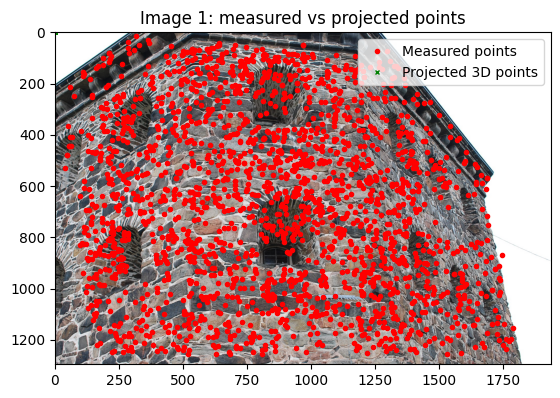

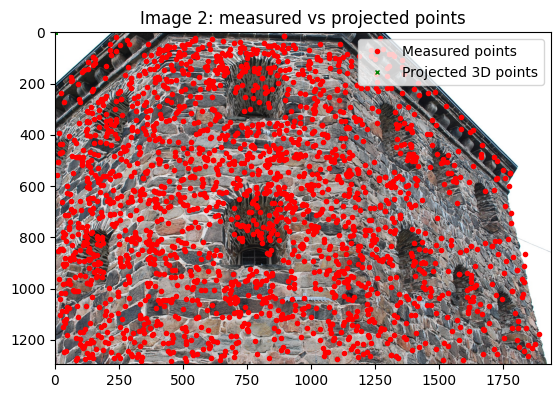

Mean reprojection error image 1: 1139.6543032035067
Mean reprojection error image 2: 1083.2310597714268
Max  reprojection error image 1: 2152.048564198719
Max  reprojection error image 2: 2236.227448302316


In [35]:
# Camera matrices in original (pixel) coordinates
P1_pix = K1_inv @ P1
P2_pix = K2_inv @ P2_best

# Project the 3D points into both images
x1_proj = P1_pix @ X_best      # 3xN
x2_proj = P2_pix @ X_best      # 3xN

x1_proj = pflat(x1_proj)       # 3xN, last row = 1
x2_proj = pflat(x2_proj)

# Inhomogeneous coordinates for plotting
x1u, x1v = x1_proj[0, :], x1_proj[1, :]
x2u, x2v = x2_proj[0, :], x2_proj[1, :]

x1_true = pflat(x1)
x2_true = pflat(x2)

x1t_u, x1t_v = x1_true[0, :], x1_true[1, :]
x2t_u, x2t_v = x2_true[0, :], x2_true[1, :]

# Plot image 1: measured vs projected points
img1 = mpimg.imread('data/kronan1.jpg')
fig, ax = plt.subplots()
ax.imshow(img1)
ax.plot(x1t_u, x1t_v, 'ro', markersize=3, label='Measured points')
ax.plot(x1u,  x1v,  'gx', markersize=3, label='Projected 3D points')
plt.legend()
plt.title('Image 1: measured vs projected points')
plt.axis('image')
plt.show()

# Plot image 2: measured vs projected points
img2 = mpimg.imread('data/kronan2.jpg')
fig, ax = plt.subplots()
ax.imshow(img2)
ax.plot(x2t_u, x2t_v, 'ro', markersize=3, label='Measured points')
ax.plot(x2u,  x2v,  'gx', markersize=3, label='Projected 3D points')
plt.legend()
plt.title('Image 2: measured vs projected points')
plt.axis('image')
plt.show()

# Quantitative reprojection error (pixels) [web:240][web:242]
err1 = np.sqrt((x1t_u - x1u)**2 + (x1t_v - x1v)**2)
err2 = np.sqrt((x2t_u - x2u)**2 + (x2t_v - x2v)**2)

print("Mean reprojection error image 1:", np.mean(err1))
print("Mean reprojection error image 2:", np.mean(err2))
print("Max  reprojection error image 1:", np.max(err1))
print("Max  reprojection error image 2:", np.max(err2))


Plot the 3D points and camera centers and principal axes in a 3D plot.
**Does it look like you expected it to ?**

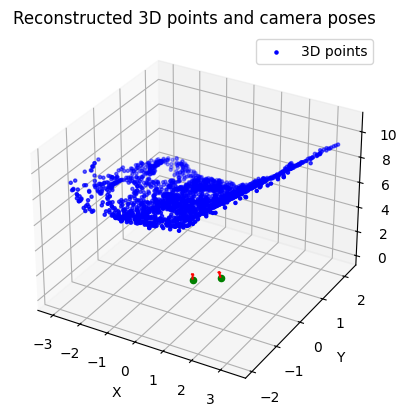

In [36]:
# Inhomogeneous 3D points
X_plot = pflat(X_best)        # 4xN -> normalize; take first 3 rows
Xx, Xy, Xz = X_plot[0, :], X_plot[1, :], X_plot[2, :]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot 3D points
ax.scatter3D(Xx, Xy, Xz, c='b', s=5, label='3D points')

# Plot the two cameras and their principal axes (normalized coordinate system)
plot_camera(P1,      scale=0.5, ax=ax)
plot_camera(P2_best, scale=0.5, ax=ax)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Reconstructed 3D points and camera poses')
ax.legend()
plt.show()

### Your answer here: 

(*Include an answer to the question marked in bold.*)
### If everything is consistent, the point cloud should form a plausible fragment of the scene located in front of both cameras, and the two camera axes should point toward it; minor irregularities or spread in depth mainly reflect image noise and limited baseline, so “small but visible” deviations are normal.